In [1]:
import os
import datetime
import colormaps
from pathlib import Path
from functools import partial
from itertools import product
from string import ascii_lowercase
from tqdm import tqdm, trange
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
from matplotlib.colors import (
    LinearSegmentedColormap,
    BoundaryNorm,
    Normalize,
    rgb_to_hsv,
    hsv_to_rgb,
)
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd
import xarray as xr
import polars as pl
import polars.selectors as cs

os.environ["PATH"] = os.environ["PATH"] + ":/opt/homebrew/bin"

from jetutils.definitions import (
    PRETTIER_VARNAME,
    YEARS,
    UNITS,
    RESULTS,
    FACTORS_UNITS,
    FACTORS,
    DATADIR,
    DUNCANS_REGIONS_NAMES,
    MONTH_NAMES,
    FIGURES,
    RADIUS,
    get_region,
    squarify,
    polars_to_xarray,
    xarray_to_polars,
    compute,
)
from jetutils.data import standardize, standardize_polars_dtypes, compute_anomalies_pl, DataHandler, open_da
from jetutils.geospatial import (
    central_diff,
    haversine_from_dl,
    compute_relative_clim,
    compute_relative_sm,
    compute_relative_std,
    compute_relative_anom,
    create_all_relative_plots,
)
from jetutils.jet_finding import (
    average_jet_categories,
    track_jets,
    pers_from_cross,
    spells_from_cross_catd_simple,
    extract_features,
    find_all_jets,
    jet_position_as_da,
    to_one_large,
)
from jetutils.plots import (
    STYLE_SHEET,
    COLORS,
    COLORS_EXT,
    WERNLI_FLAIR,
    WERNLI_FLAIR_LEVELS,
    Clusterplot,
    plot_interp,
    plot_relative_time,
    gaussian_kde,
)
from jetutils.anyspell import (
    make_daily,
    mask_from_spells_pl,
    subset_around_onset,
    extend_spells,
    get_spells,
)
from jetutils.stats import create_bootstrapped_times, odds_ratio, is_signif_OR, common_OR

%load_ext IPython.extensions.autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.print_figure_kwargs = {'bbox_inches':None}

basepath = Path(f"{DATADIR}/ERA5/plev/high_wind/6H/results/9")

ALL_TIMES = (
    pl.datetime_range(
        start=pl.datetime(1959, 1, 1),
        end=pl.datetime(2023, 1, 1),
        closed="left",
        interval="6h",
        eager=True,
        time_unit="ms",
    )
    .rename("time")
    .to_frame()
)
summer_filter = ALL_TIMES.filter(pl.col("time").dt.month().is_in([6, 7, 8, 9])).filter(
    pl.col("time").dt.ordinal_day() > 166
)
summer = summer_filter["time"]
summer_daily = summer.filter(summer.dt.hour() == 0)
big_summer = ALL_TIMES.filter(pl.col("time").dt.month().is_in([6, 7, 8, 9]))
big_summer_daily = big_summer.filter(big_summer["time"].dt.hour() == 0)

no xgboost found
No shap


In [2]:
all_jets = pl.read_parquet(basepath.joinpath("jets.parquet"))
phat_jets = to_one_large(all_jets)
props = pl.read_parquet(basepath.joinpath("props.parquet"))
cross = pl.read_parquet(basepath.joinpath("cross.parquet"))
pers = pers_from_cross(cross)
props = props.join(pers, on=["time", "jet ID"])

over_europe = pl.col("lon") > -10
lat_over_europe = (pl.col("lat") * pl.col("s")).filter(over_europe).sum() / pl.col(
    "s"
).filter(over_europe).sum()
lat_over_europe = all_jets.group_by("time", "jet ID").agg(
    lat_over_europe.fill_nan(0).alias("lat_over_europe")
)
props = props.join(lat_over_europe, on=["time", "jet ID"])

props_catd = squarify(average_jet_categories(props), ["time", "jet"])
props_catd = props_catd.join(
    props_catd.rolling("time", period="2d", group_by="jet").agg(
        **{
            f"{col}_var": pl.col(col).var()
            for col in ["mean_lon", "mean_lat", "mean_s", "s_star"]
        }
    ),
    on=["time", "jet"],
)

cross_catd_ofile = basepath.joinpath("cross_catd.parquet")
if cross_catd_ofile.is_file():
    cross_catd = pl.read_parquet(cross_catd_ofile)
else:
    cross_catd = track_jets(phat_jets)
    cross_catd.write_parquet(cross_catd_ofile)
pers_catd = pers_from_cross(cross_catd).rename({"pers": "pers_catd"})

phat_filter = (pl.col("is_polar") < 0.5) | (
    (pl.col("is_polar") > 0.5) & (pl.col("int") > 1.3e8)
)
phat_props = props.filter(phat_filter)
phat_props = squarify(average_jet_categories(phat_props), ["time", "jet"])
phat_props = phat_props.join(
    phat_props.rolling("time", period="2d", group_by="jet").agg(
        **{
            f"{col}_var": pl.col(col).var()
            for col in ["mean_lon", "mean_lat", "mean_s", "s_star"]
        }
    ),
    on=["time", "jet"],
)
phat_props_summer = summer_filter.join(phat_props, on="time")


spells_list = spells_from_cross_catd_simple(
    cross_catd,
    season=summer_filter,
    q_STJ=0.765,
    q_EDJ=0.83,
    minlen=datetime.timedelta(days=5),
    smooth=datetime.timedelta(hours=24),
    fill_holes=datetime.timedelta(hours=18),
)
for jet, spells in spells_list.items():
    print(jet, spells["spell"].n_unique())

daily_spells_list = {
    a: make_daily(b, "spell", ["len", "spell_of"]) for a, b in spells_list.items()
}

ds = xr.open_dataset(basepath.joinpath("da.nc"))

STJ 30
EDJ 30


# Persistence quantiles vs props

In [14]:
opath_dim = exp.path.joinpath("dim.parquet")
opath_theta = exp.path.joinpath("theta.parquet")
if opath_dim.is_file() and opath_theta.is_file():
    dim_pd = pl.read_parquet(opath_dim)
    theta_pd = pl.read_parquet(opath_theta)
else:
    import CDSK
    da_ = coarsen_da(exp.ds["s"].sel(time=np.isin(exp.ds.time.dt.month, [6, 7, 8, 9])), 4, np.amax)
    # da_anom = compute_anomalies_ds(da_, "dayofyear", standardized=True).sel(time=np.isin(da_.time.dt.month, [6, 7, 8, 9]))
    X = da_.values.reshape(da_.shape[0], -1)
    a, b, c = CDSK.dynamical_local_indexes(X, n_jobs=N_WORKERS)
    dim = a[:, 0, 0]
    theta = b[:, 0, 0]
    dim_pd = pl.DataFrame({"time": da_.time.values, "dim": dim})
    theta_pd = pl.DataFrame({"time": da_.time.values, "theta": theta})
    dim_pd.write_parquet(opath_dim)
    theta_pd.write_parquet(opath_theta)

NameError: name 'exp' is not defined

In [ ]:
speed_realspace = ((da_[1:].data - da_[:-1].data) ** 2).sum(axis=(1, 2))
speed_pd = pl.DataFrame({"time": da_.time.values[:-1], "speed": speed_realspace})
pers_ = pers_from_cross_catd(cross_catd).filter(pl.col("time").dt.month().is_in([6, 7, 8, 9]))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3), constrained_layout=True)
axes = axes.ravel()
for i, to_plot in enumerate([dim_pd, theta_pd, speed_pd]):
    ax = axes[i]
    name = to_plot.columns[-1]
    for jet in ["STJ", "EDJ"]:
        spells = spells_list[jet]
        huh = mask_from_spells_pl(spells_list[jet], to_plot, time_before=datetime.timedelta(days=4))
        x, y = huh.group_by("relative_index").mean().sort("relative_index")[["relative_index", name]].to_numpy().T
        x = x / 4
        ax.plot([x[0], x[-1]], [to_plot[name].mean()] * 2, color="black")
        ax.plot(x, y, color=COLORS[2 - int(jet=="EDJ")], lw=3, label=jet[:3])
    ax.set_xlabel("Relative time around offset [day]")
axes[0].set_title("Local dimension $d$")
axes[1].set_title(r"Extremal factor $\theta$")
axes[2].set_title(r"Realspace speed")
axes[0].legend(ncol=2)
fig.savefig(f"{FIGURES}/jet_persistence/dst.png")

In [ ]:
from itertools import pairwise
props_as_df_anoms = compute_anomalies_pl(phat_props_catd.filter(pl.col("time").dt.month().is_in([6, 7, 8, 9])), standardize=True)
from jetutils.jet_finding import pers_from_cross_catd
pers_ = pers_from_cross_catd(cross_catd).filter(pl.col("time").dt.month().is_in([6, 7, 8, 9]))
n_q = 31
data_vars = [
    "mean_lat",
    "mean_theta",
    "mean_s",
    "tilt",
    "waviness1",
    "width",
]
prettier_index = {
    "theta": "Inv. DST extremal index",
    "dim": "DST local dimension",
    "speed": "Inv. T2T distance",
    "pers": "Jet persistence",
}
cm = colormaps.bold
colors_props = cm(np.linspace(0, 1 - 1 / cm.N, cm.N) + 1 / 2 / cm.N)
vs_quantiles = {
    data_var: np.zeros(n_q - 1) for data_var in data_vars
}
qs = np.linspace(0, 1, n_q)
to_plots = {"theta": theta_pd, "dim": dim_pd, "speed": speed_pd, "pers": pers}
fig, axes = plt.subplots(len(to_plots), 2, figsize=(10, 10), sharex="all", sharey="col", gridspec_kw={"hspace": 0.23})
for i, (name, to_plot) in enumerate(to_plots.items()):
    name = to_plot.columns[-1]
    for j, jet in enumerate(["STJ", "EDJ"]):
        ax = axes[i, j]
        if name=="pers":
            to_plot_ = to_plot.filter(pl.col("spell_of") == jet)
        elif name in ["theta", "speed"]:
            to_plot_ = to_plot.with_columns(1 / pl.col(name))
        else:
            to_plot_ = to_plot
        to_plot_ = to_plot.cast({"time": pl.Datetime("ms")})
        for k, (q1, q2) in enumerate(pairwise(qs)):
            props = (
                to_plot_
                .filter(
                    (pl.col(name) < pl.col(name).quantile(q2)) & 
                    (pl.col(name) >= pl.col(name).quantile(q1))
                )[["time"]]
                .join(
                    props_as_df_anoms
                    .filter(pl.col("jet") == jet), 
                    on="time"
                )
                .mean()
            )
            for data_var in data_vars:
                vs_quantiles[data_var][k] = props[data_var].item()
            ax.axhline(0, color="black")
        for k, (data_var, huh) in enumerate(vs_quantiles.items()):
            ax.plot((qs[:-1] + qs[1:]) / 2, huh, label=PRETTIER_VARNAME[data_var], color=colors_props[k], lw=2)
        ax.set_title(f"{prettier_index[name]}, props. of the {jet[:3]}", pad=4)
fig.supxlabel("Quantile of the persistence prop.", y=0.05)
fig.supylabel("Standardized anomaly of the jet property", x=0.06)
axes[-1, 0].legend(bbox_to_anchor=[2, -.35], ncol=3, title="Jet properties")
axes[-1, -1].set_xlim([0, 1])
fig.savefig(f"{FIGURES}/jet_persistence/pers_props_quantiles.png")

# grams weather regimes

In [ ]:
dh = DataHandler.from_specs("ERA5", "plev", "z", "6H", "all", [6, 7, 8, 9], -80, 40, 15, 80, 500, "dayofyear", {"dayofyear": ("win", 15)}, None)

exp_z = Experiment(dh)
centers_z, labels_z = exp_z.do_kmeans(4, 30, weigh_grams=False)

coslat = np.cos(np.deg2rad(centers_z.lat))
Pwr = (dh.da * centers_z * coslat).sum(["lon", "lat"]) / coslat.sum() / centers_z.lon.shape[0]
Iwr = (Pwr - Pwr.mean("time")) / Pwr.std("time", ddof=0)
Iwr = compute(Iwr)
Iwr = xarray_to_polars(Iwr.rename("Iwr")).drop("ratio", "label")

# Iwr = Iwr.with_columns(year=pl.col("time").dt.year())
sigma_wr = Iwr["Iwr"].std()
winner = Iwr.group_by("time", maintain_order=True).agg(pl.col("Iwr").arg_max().alias("winner"), pl.col("Iwr").max(), pl.col("time").dt.year().alias("year").first())
winner = winner.with_columns(winner=pl.when(pl.col("Iwr") > sigma_wr).then(1 + pl.col("winner")).otherwise(pl.lit(0)))
start_of_year = winner.group_by("year", maintain_order=True).len().with_columns(start_of_year=pl.col("len").cum_sum() - pl.col("len").get(0)).drop("len")
to_zero = (
    winner
    .group_by("year", maintain_order=True)
    .agg(pl.col("winner").rle().alias("rle"))
    .explode("rle")
    .unnest("rle")
    .group_by("year", maintain_order=True)
    .agg(
        len=pl.col("len"),
        start=pl.lit(0).append(
            pl.col("len").cum_sum().slice(0, pl.col("len").len() - 1)
        ),
        value=pl.col("value"),
    )
    .explode(["len", "start", "value"])
    .join(start_of_year, on="year")
    .with_columns(start=pl.col("start") + pl.col("start_of_year"))
    .drop("start_of_year")
    .filter(pl.col("len") < 20, pl.col("value") > 0)
    .drop("value")
    .with_columns(
        index=pl.int_ranges(pl.col("start"), pl.col("start") + pl.col("len"))
    )
    .drop("len", "start")
    .explode("index")
)[:, "index"]
winner[to_zero, "winner"] = 0

mask_updated = labels_to_mask(winner[:, "winner"].to_numpy())

In [ ]:
["Greenland Blocking", "Zonal regime", "EuBL/AR", "ScBl"]

In [ ]:
clu = Clusterplot(2, 2, get_region(exp_z.da))
clu.add_contourf([dh.da[winner["winner"] == i].mean("time") / 9.8 for i in range(1, 5)], cmap=colormaps.BlWhRe, levels=[-100, - 60, -20, 20, 60, 100], titles=[str(i) for i in range(1, 5)])
a = 1

In [ ]:
winner.write_parquet(dh.path.joinpath("grams_wr.parquet"))

# Real space composites

## data over europe

In [3]:
args1 = ["all", [6, 7, 8, 9], -10, 40, 30, 70]
args2 = ["dayofyear", {"dayofyear": ("win", 15)}]

da_T_anom_europe = DataHandler.from_specs(
    "ERA5",
    "surf",
    "t2m",
    "6H",
    *args1,
    "all",
    *args2,
).da
da_T_anom_europe = compute(da_T_anom_europe, progress_flag=True)
da_tp_anom = DataHandler.from_specs(
    "ERA5",
    "surf",
    "tp",
    "6H",
    *args1,
    "all",
    *args2,
).da
da_tp_anom = compute(da_tp_anom, progress_flag=True)
da_z500_anom = DataHandler.from_specs(
    "ERA5",
    "plev",
    "z",
    "6H",
    *args1, 
    500,
    *args2,
).da
da_z500_anom = compute(da_z500_anom, progress_flag=False).rename("z500") / 9.8

[########################################] | 100% Completed | 4.63 ss
[########################################] | 100% Completed | 3.02 ss


## data over Natl

In [30]:
args1 = ["all", [6, 7, 8, 9], *get_region(ds)]
args2 = ["dayofyear", {"dayofyear": ("win", 15)}]

da_tp = DataHandler.from_specs(
    "ERA5",
    "surf",
    "tp",
    "6H",
   "all", 
   [6, 7, 8, 9], 
   *(-80, 40, 0, 90)
).da
da_tp = compute(da_tp, progress_flag=True)
da_theta2pvu = DataHandler.from_specs(
    "ERA5",
    "surf",
    ("alot2pvu", "theta"),
    "6H",
    *args1
).da
da_theta2pvu = compute(da_theta2pvu, progress_flag=True)
da_T_anom = DataHandler.from_specs(
    "ERA5",
    "surf",
    "t2m",
    "6H",
    "all", 
    [6, 7, 8, 9], 
    *(-80, 40, 0, 90),
    "all",
    *args2,
).da
da_T_anom = compute(da_T_anom, progress_flag=True)

varnames_rwb = ["APVO", "CPVO"]
das_rwb = {}
for var in varnames_rwb:
    das_rwb[var] = compute(DataHandler.from_specs("ERA5", "thetalev", var, "6H", *args1, reduce_da=False).da, progress_flag=True)
ds_ = compute(ds.isel(time=np.isin(ds.time.dt.month, [6, 7, 8, 9])), progress_flag=True)

[########################################] | 100% Completed | 4.03 ss
[########################################] | 100% Completed | 20.55 s
[########################################] | 100% Completed | 193.92 s
[########################################] | 100% Completed | 2.42 ss
[########################################] | 100% Completed | 2.32 ss


In [ ]:
# from jetutils.anyspell import regionalize
# region_T_ts = regionalize(da_T_anom, clusters_da, ["time"])
# region_tp_ts = regionalize(da_tp_anom, clusters_da, ["time"])

In [ ]:
# region_T_ts.write_parquet("/storage/workspaces/giub_meteo_impacts/ci01/ERA5/surf/t2m/dailymean/dayofyear_doywin15/results/1/regionalized.parquet")

In [ ]:
# region_tp_ts.write_parquet("/storage/workspaces/giub_meteo_impacts/ci01/ERA5/surf/tp/dailysum/dayofyear_doywin15/results/1/regionalized.parquet")

## composites, all spells

100%|██████████| 2/2 [00:00<00:00, 365.20it/s]


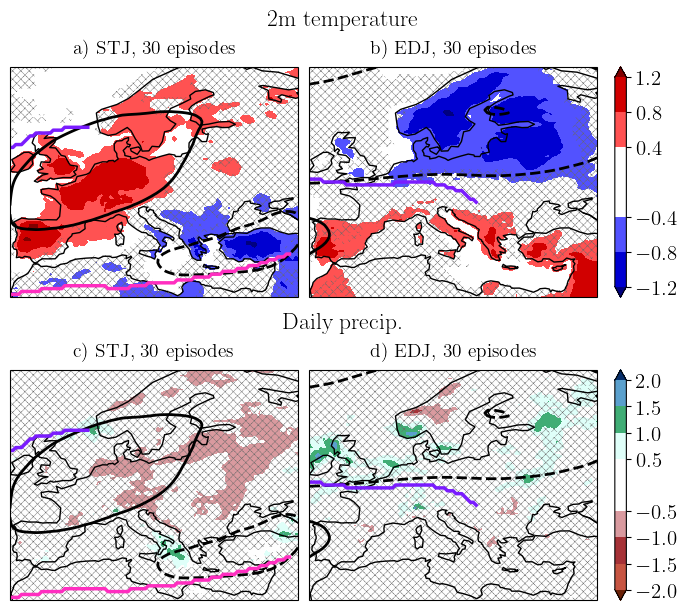

In [ ]:
from jetutils.jet_finding import gaussian_smooth_func
from string import ascii_lowercase
from cartopy.mpl.geoaxes import GeoAxes
plt.rc("axes", titlesize=14)
da_contour = da_z500_anom.sel(time=da_z500_anom.time.dt.year>=1959)
da_1 = da_T_anom_europe
cbar_kwargs = {"shrink": 1.0, "fraction": 0.11, "pad": 0.03}
plot_kwargs_1 = {
    "cmap": colormaps.BlWhRe, 
    "levels": [-1.2, -0.8, -.4, .4, 0.8, 1.2], 
    "transparify": 1, 
    "cbar_kwargs": cbar_kwargs
}
da_2 = da_tp_anom * 1000
plot_kwargs_2 = {
    "cmap": colormaps.precip4_diff_19lev,
    "levels": np.linspace(-2, 2, 9).tolist(),
    "transparify": 0, 
    "cbar_kwargs": cbar_kwargs,
}
stippling_kwargs = {
    "FDR": True,
    "invert": True,
    "linewidth": 0.3,
    "color": "dimgrey",
    "hatch": "xxxx",
}
nrow, ncol = 1, 2
days_around = 5
n = nrow * ncol
cmap = colormaps.pastel
norm = BoundaryNorm(np.arange(cmap.N) + 0.5, cmap.N)
bigfig = plt.figure(figsize=(6.8, 6), constrained_layout=True)
subfigs = bigfig.subfigures(2, 1)
for da, plot_kwargs, fig in zip([da_1, da_2], [plot_kwargs_1, plot_kwargs_2], subfigs):
    clu = Clusterplot(nrow, ncol, get_region(da), fig=fig)
    mask = np.zeros((len(da.time), len(spells_list)), dtype=bool)
    titles = []
    for j, jet in enumerate(spells_list):
        spells_from_jet = subset_around_onset(spells_list[jet], around_onset=datetime.timedelta(days=days_around))
        letter = ascii_lowercase[j % len(ascii_lowercase) + len(clu.axes) * int(da.name == "tp")]
        mask[:, j] = np.isin(
            da.time.values,
            spells_from_jet["time"]
        )
        n_spells = spells_from_jet["spell"].n_unique()
        titles.append(f"{letter}) {jet[:3]}, {n_spells} episodes")
    _ = clu.add_any_contour_from_mask(da, mask, type="contourf", stippling=True, titles=titles, stippling_kwargs=stippling_kwargs, **plot_kwargs)
    # _ = clu.add_any_contour_from_mask(da, mask, type="contourf", stippling=False, titles=titles, stippling_kwargs=None, **plot_kwargs)
    _ = clu.add_any_contour_from_mask(da_contour, mask, type="contour", levels=[-60, -20, 20, 60], linewidths=2., clabels=False)
    fig.suptitle(PRETTIER_VARNAME.get(da.name, da.name))
    
masked_da = []
time_name = "time"
reduction_function = np.nanmean
for mas in mask.T:
    masked_da.append(ds_.isel({time_name: mas}).reduce(reduction_function, dim=time_name))
masked_da = xr.concat(masked_da, dim="relative_index")
find_jets_kwargs = dict(
    n_coarsen=1,
    base_s_thresh=20,
    alignment_thresh=0.6,
    int_thresh_factor=0.6,
    hole_size=6,
    smooth_func=partial(gaussian_smooth_func, sigma_lon=2, sigma_lat=0.8),
)
jets_on_mean = find_all_jets(masked_da, **find_jets_kwargs)
for fig in subfigs:
    for ax, (_, jets) in zip(fig.axes, jets_on_mean.group_by("relative_index")):
        if not isinstance(ax, GeoAxes):
            continue
        for _, jet_ in jets.group_by("jet ID"):
            lo, la = jet_[["lon", "lat"]]
            if la.mean() > 40: 
                color = COLORS[1]
            else:
                color = COLORS[2]
            ax.plot(lo - clu.central_longitude, la, lw=2.5, color=color)
# bigfig.savefig(f"{FIGURES}/jet_persistence/realspace_stuff/t2m_and_tp_realspace_both_30spells.png")

#### just plot data

In [ ]:
from jetutils.stats import field_significance
from string import ascii_lowercase
from cartopy.mpl.geoaxes import GeoAxes

reduction_function = np.nanmean
plt.rc("axes", titlesize=14)
da_contour = da_z500_anom.sel(time=da_z500_anom.time.dt.year>=1959)
da_1 = da_T_anom_europe
da_2 = da_tp_anom * 1000
days_around = 3
mask = np.zeros((len(da_contour.time), len(spells_list)), dtype=bool)
time_name = "time"
for j, jet in enumerate(spells_list):
    spells_from_jet = subset_around_onset(spells_list[jet], around_onset=datetime.timedelta(days=days_around))
    mask[:, j] = np.isin(
        da_contour.time.values,
        spells_from_jet["time"]
    )
    n_spells = spells_from_jet["spell"].n_unique()

to_plot = {}
signifs = {}
for da in [da_1, da_2]:
    to_plot_cf = []
    for mas in tqdm(mask.T, total=mask.shape[1]):
        if np.sum(mas) < 1:
            to_plot_cf.append(da[0].copy(data=np.zeros(da.shape[1:])))
            continue
        to_plot_cf.append(da.isel({time_name: mas}).reduce(reduction_function, dim=time_name))
    to_plot[da.name] = xr.concat(to_plot_cf, dim="jet")
    
    to_test = []
    for mas in mask.T:
        if np.sum(mas) < 1:
            to_test.append(da[:1].copy(data=np.zeros((1, *da.shape[1:]))))
            continue
        to_test.append(da.isel(time=mas))
    significances = []
    da_ = da.values
    # da = np.sort(da, axis=0)
    for i in trange(mask.shape[1]):
        this_signif = field_significance(to_test[i], da_, 200, q=0.1)[1]
        this_signif = da[0].copy(data=this_signif).reset_coords("time", drop=True)
        significances.append(this_signif)
    signifs[da.name] = xr.concat(significances, dim="jet")
    
to_plot = xr.Dataset(to_plot)
signifs = xr.Dataset(signifs)
    
to_plot_c = []
for mas in tqdm(mask.T, total=mask.shape[1]):
    if np.sum(mas) < 1:
        to_plot_c.append(da_contour[0].copy(data=np.zeros(da.shape[1:])))
        continue
    to_plot_c.append(da_contour.isel({time_name: mas}).reduce(reduction_function, dim=time_name))
to_plot_c = xr.concat(to_plot_c, dim="jet")
    
masked_da = []
time_name = "time"
reduction_function = np.nanmean
for mas in mask.T:
    masked_da.append(ds_.isel({time_name: mas}).reduce(reduction_function, dim=time_name))
masked_da = xr.concat(masked_da, dim="relative_index")
find_jets_kwargs = dict(
    n_coarsen=1,
    base_s_thresh=20,
    alignment_thresh=0.6,
    int_thresh_factor=0.6,
    hole_size=6,
    smooth_func=partial(gaussian_smooth_func, sigma_lon=2, sigma_lat=0.8),
)
jets_on_mean = find_all_jets(masked_da, **find_jets_kwargs)

to_plot.to_netcdf("/storage/homefs/hb22g102/jetutils/Results/figure_data_pers/contourf.nc")
signifs.to_netcdf("/storage/homefs/hb22g102/jetutils/Results/figure_data_pers/signifs.nc")
to_plot_c.to_netcdf("/storage/homefs/hb22g102/jetutils/Results/figure_data_pers/contour.nc")
masked_da.to_netcdf("/storage/homefs/hb22g102/jetutils/Results/figure_data_pers/wind.nc")

100%|██████████| 2/2 [00:00<00:00, 224.36it/s]


## Individual spells

#### the case study plot

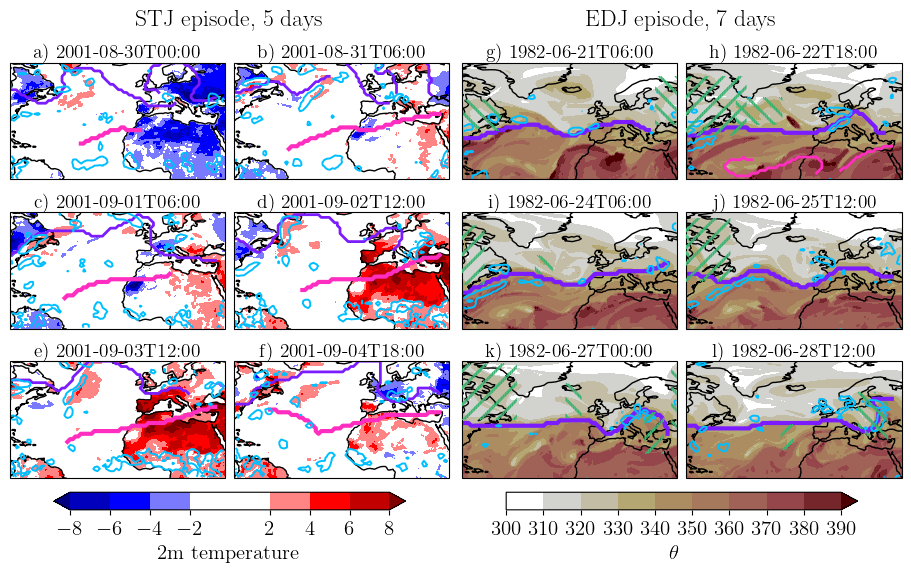

In [31]:
from jetutils.data import compute_anomalies_pl, coarsen_da

n_stj = 16
n_edj = 9
figure = plt.figure(layout='constrained', figsize=(9, 5.6))
subfigs = figure.subfigures(1, 2, wspace=0.01)
fig1, fig2 = subfigs
nrow, ncol = 3, 2
n = nrow * ncol
plt.rc("axes", titlesize=14)
plt.rc("axes", titlepad=2)

rwb_color = "mediumseagreen"
rwb_lw = 2

cbar_kwargs = {"location": "bottom", "shrink": 0.8, "fraction": 0.1, "pad": 0.03}
plot_kwargs_all = {
    "STJ": {"cmap": colormaps.BlWhRe, "levels": MaxNLocator(9).tick_values(-8, 8).tolist(), "cbar_kwargs": cbar_kwargs},
    "EDJ": {"cmap": colormaps.bilbao_r, "levels": MaxNLocator(11).tick_values(300, 390).tolist(), "cbar_kwargs": cbar_kwargs},
}

for fig, key, da, which_spell in zip(subfigs, ["STJ", "EDJ"], [da_T_anom, da_theta2pvu], [n_stj, n_edj]):
    is_edj = key == "EDJ"
    plot_kwargs = plot_kwargs_all[key]
    region = (-80, 40, 15, 80) if key == "EDJ" else (-80, 40, 0, 65)
    clu = Clusterplot(nrow, ncol, region, row_height=3.5, fig=fig)
    spell = spells_list[key].filter(pl.col("spell") == which_spell)
    spell = extend_spells(spell, time_before=datetime.timedelta(days=0))
    len_spell = spell["time"][-1] - spell["time"][0]
    
    times = pl.linear_space(spell["time"][0], spell["time"][-1], n, eager=True).dt.round("6h").cast(pl.Datetime("ms"))
    titles = times.dt.to_string("%Y-%m-%dT%H:00").to_list()
    titles = [f"{ascii_lowercase[n * is_edj + i]}) {title}" for i, title in enumerate(titles)]
    to_plot = da.sel(time=times)
    clu.add_contourf(to_plot, titles=titles, cbar_label=PRETTIER_VARNAME.get(da.name, da.name), **plot_kwargs)
    fig.suptitle(f"{key} episode, " + str(len_spell)[:6])
    
    for i, t in enumerate(times):
        if i == 0 and t < spell["time"][0]:
            t_ = spell["time"][0]
        else:
            t_ = t
        jets = all_jets.filter(pl.col("time") == t_)
        for _, jet in jets.group_by("jet ID"):
            lo, la, is_p = jet[["lon", "lat", "is_polar"]]
            this_jet_is_p = len(is_p) > 0 and is_p.mean() > 0.45
            color = COLORS[1] if this_jet_is_p else COLORS[2]
            lw = 2 + 1 * (is_edj == this_jet_is_p)
            clu.axes[i].plot(lo - clu.central_longitude, la, color=color, lw=lw)
    # if key == "STJ":
    #     to_plot = da_z500_anom.sel(time=times)
    #     clu.add_contour(to_plot, levels=[-200, -100, 100, 200], colors="black", linewidths=2.)
    # if key == "STJ":
    #     to_plot = coarsen_da(da_tp.sel(time=times), 5)
    #     clu.add_contour(to_plot < 1e-5, levels=[0.5], colors=["green"], linewidths=3)
    #     break
    to_plot = coarsen_da(da_tp.sel(time=times), 3)
    clu.add_contour(to_plot * 1000, levels=[25], colors=["deepskyblue"], linewidths=1.4)
    if key == "EDJ":
        to_plot = das_rwb["APVO"].sel(time=times, lev=slice(320, 340)).any("lev")
        for ax, ouais in zip(clu.axes, to_plot):
            cs = ax.pcolor(
                to_plot.lon.values - clu.central_longitude,
                to_plot.lat.values,
                ouais.where(ouais),
                hatch="//", 
                facecolor="none", 
                edgecolor=rwb_color, 
                hatch_linewidth=rwb_lw, 
                linewidth=0,
                zorder=100
            )
        to_plot = das_rwb["CPVO"].sel(time=times, lev=slice(320, 340)).any("lev")
        for ax, ouais in zip(clu.axes, to_plot):
            cs = ax.pcolor(
                to_plot.lon.values - clu.central_longitude,
                to_plot.lat.values,
                ouais.where(ouais),
                hatch=r"\\",
                facecolor="none", 
                edgecolor=rwb_color, 
                hatch_linewidth=rwb_lw, 
                linewidth=0,
                zorder=100
            )
    
figure.savefig(f"{FIGURES}/jet_persistence/realspace_stuff/case_study_both.pdf")

#